In [1]:
from platform import python_version
print(python_version())
# Make sure version is 3.7-3.11

3.10.19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

In [ ]:
# Only supported on windows
import nanoscope
from nanoscope import files
from nanoscope.constants import FORCE, METRIC, VOLTS, PLT_kwargs

In [ ]:
#freq: Probe modulation frequency
freq=10
def sinewlinearBL(x,A,P,C,a):
    return A*np.sin(freq*(2*np.pi)*x+P)+C+a*x

In [7]:
#List of IR frequencies
IRfreqs=[5,10,20,40,60,80,100,140,180,220]
IRfreqs=IRfreqs+[n for n in range(240,400,20)]

lt    -0.277311
ps    -0.044459
sp     4.916795
spp   -1.360058
dtype: float64

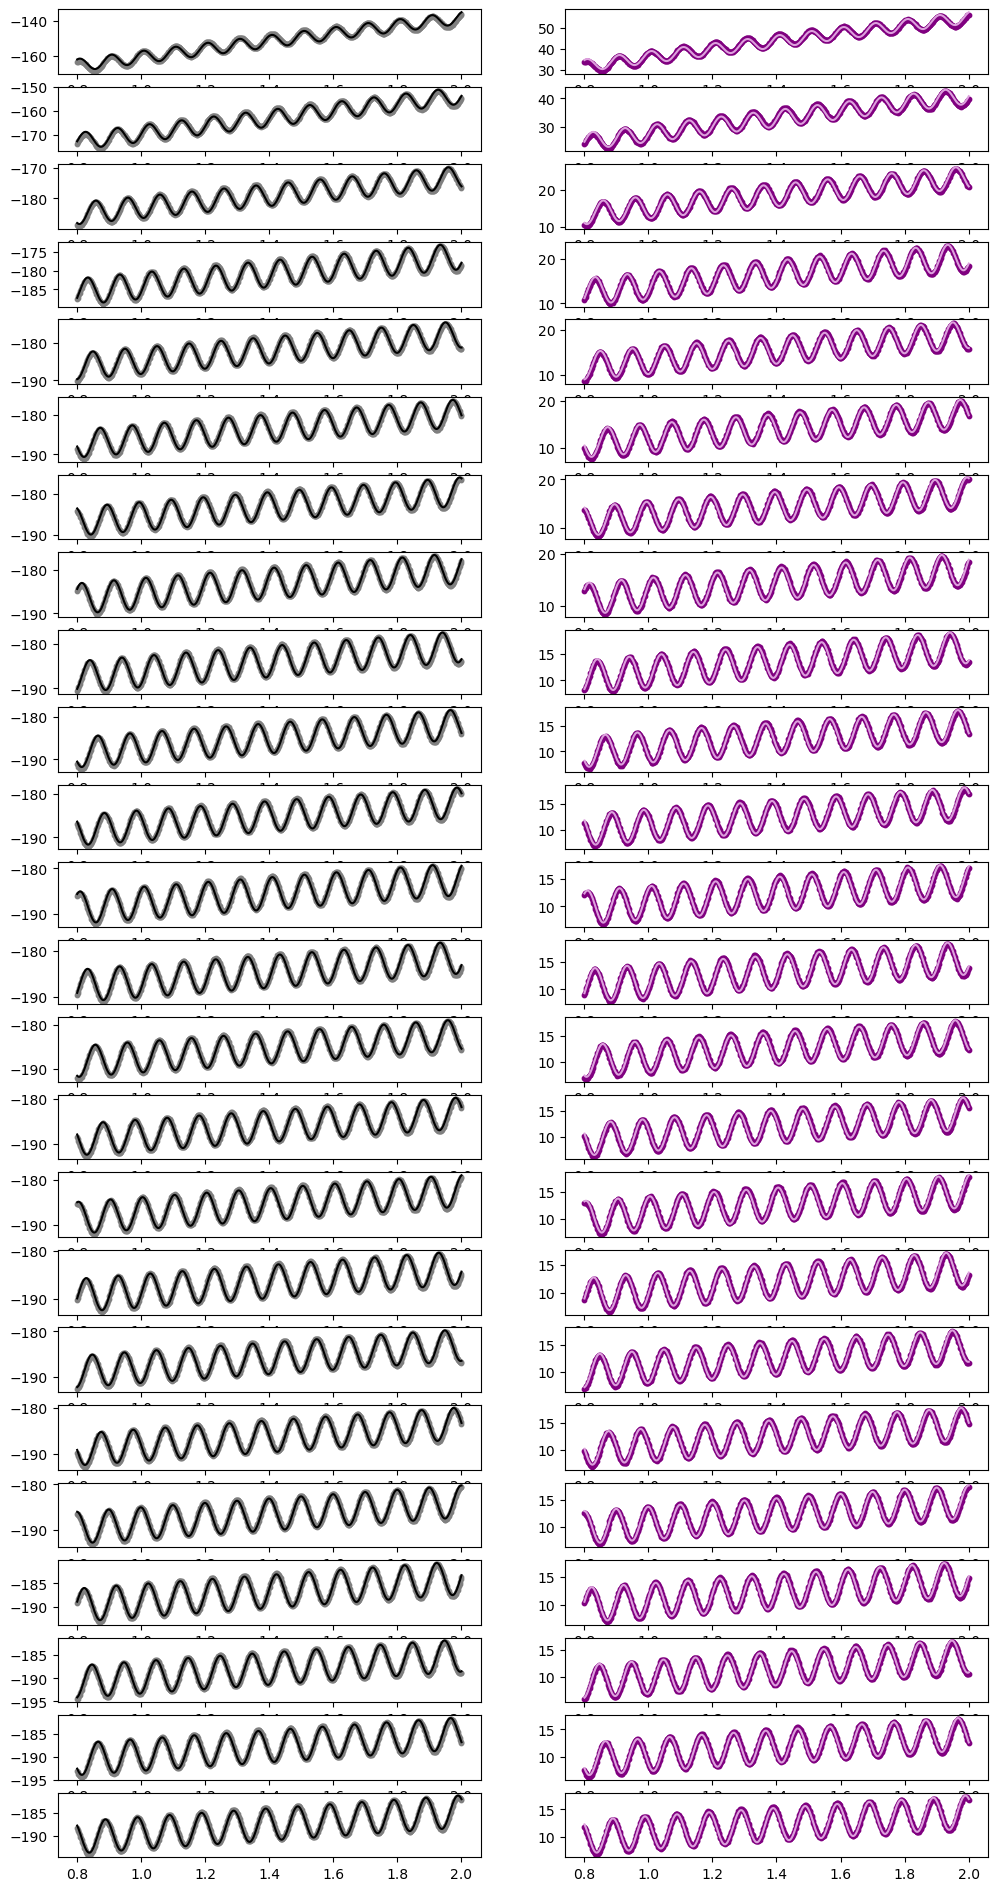

In [12]:
# calibration (sapphire)
filepath=r'example_data\1\Sapp\Sapp.0_000'
filecount=24

psi=[]
phi=[]
Zamp=[]
Damp=[]
fig2,ax2=plt.subplots(filecount,2,figsize=(12,filecount))


for n in range(filecount):
    if n<10:
        N=str(0)+str(n)
    else:
        N=n
    file=filepath+'{}.spm'.format(N)
    with files.HoldCurveFile(file) as file_:
        channel = file_[0]
        hold_plot, ax_properties = channel.create_force_hold_time_plot(METRIC)
        time=hold_plot.x
        d=hold_plot.y
        channel = file_[1]
        hold_plot, ax_properties = channel.create_force_hold_time_plot(METRIC)
        z=hold_plot.y
    
    #height
    x=time[400:]
    y=z[400:]
    ax2[n,0].scatter(x,y,s=10,color="grey")
    bounds=[[0,0,-np.inf,-np.inf],[np.inf,np.inf,np.inf,np.inf]]
    z_guess,z_guess_err = curve_fit(sinewlinearBL,x,y,p0=[3,300,0,0],bounds=bounds)
    yfit=sinewlinearBL(x,*z_guess)
    ax2[n,0].plot(x,yfit,c='k')
    
    
    #defl
    ax3=ax2[n,1]
    X=time[400:]
    Y=d[400:]
    ax3.scatter(X,Y,s=10,color="purple")
    
    d_guess,d_guess_err = curve_fit(sinewlinearBL,X,Y,p0=[3,z_guess[1],0,0],bounds=bounds)
    Yfit=sinewlinearBL(X,*d_guess)
    ax3.plot(X,Yfit,c='plum')

    psi.append(z_guess[1])
    phi.append(d_guess[1])
    Zamp.append(z_guess[0])
    Damp.append(d_guess[0])


lt=[]
ps=[]
sp=[]
spp=[]
dzr=[]
for n in range(4):
    phaseshift=phi[n]-psi[n]
    DZr=(Damp[n]/Zamp[n])

    ps.append(phaseshift)
    dzr.append(DZr)
    sp.append(DZr*(np.cos(phaseshift)-DZr)/
              ((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))

    spp.append(DZr*np.sin(phaseshift)/
              ((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))
     

    lt.append(np.sin(phaseshift)/(np.cos(phaseshift)-DZr))

combined=pd.DataFrame({'lt':lt,
         'ps':ps,
         'sp':sp,
         'spp':spp})
pd.set_option('display.max_rows', None)
combined.mean(axis=0)

### ps -> phase shift needed to correct subsequent values. from above, average ps=-0.044459

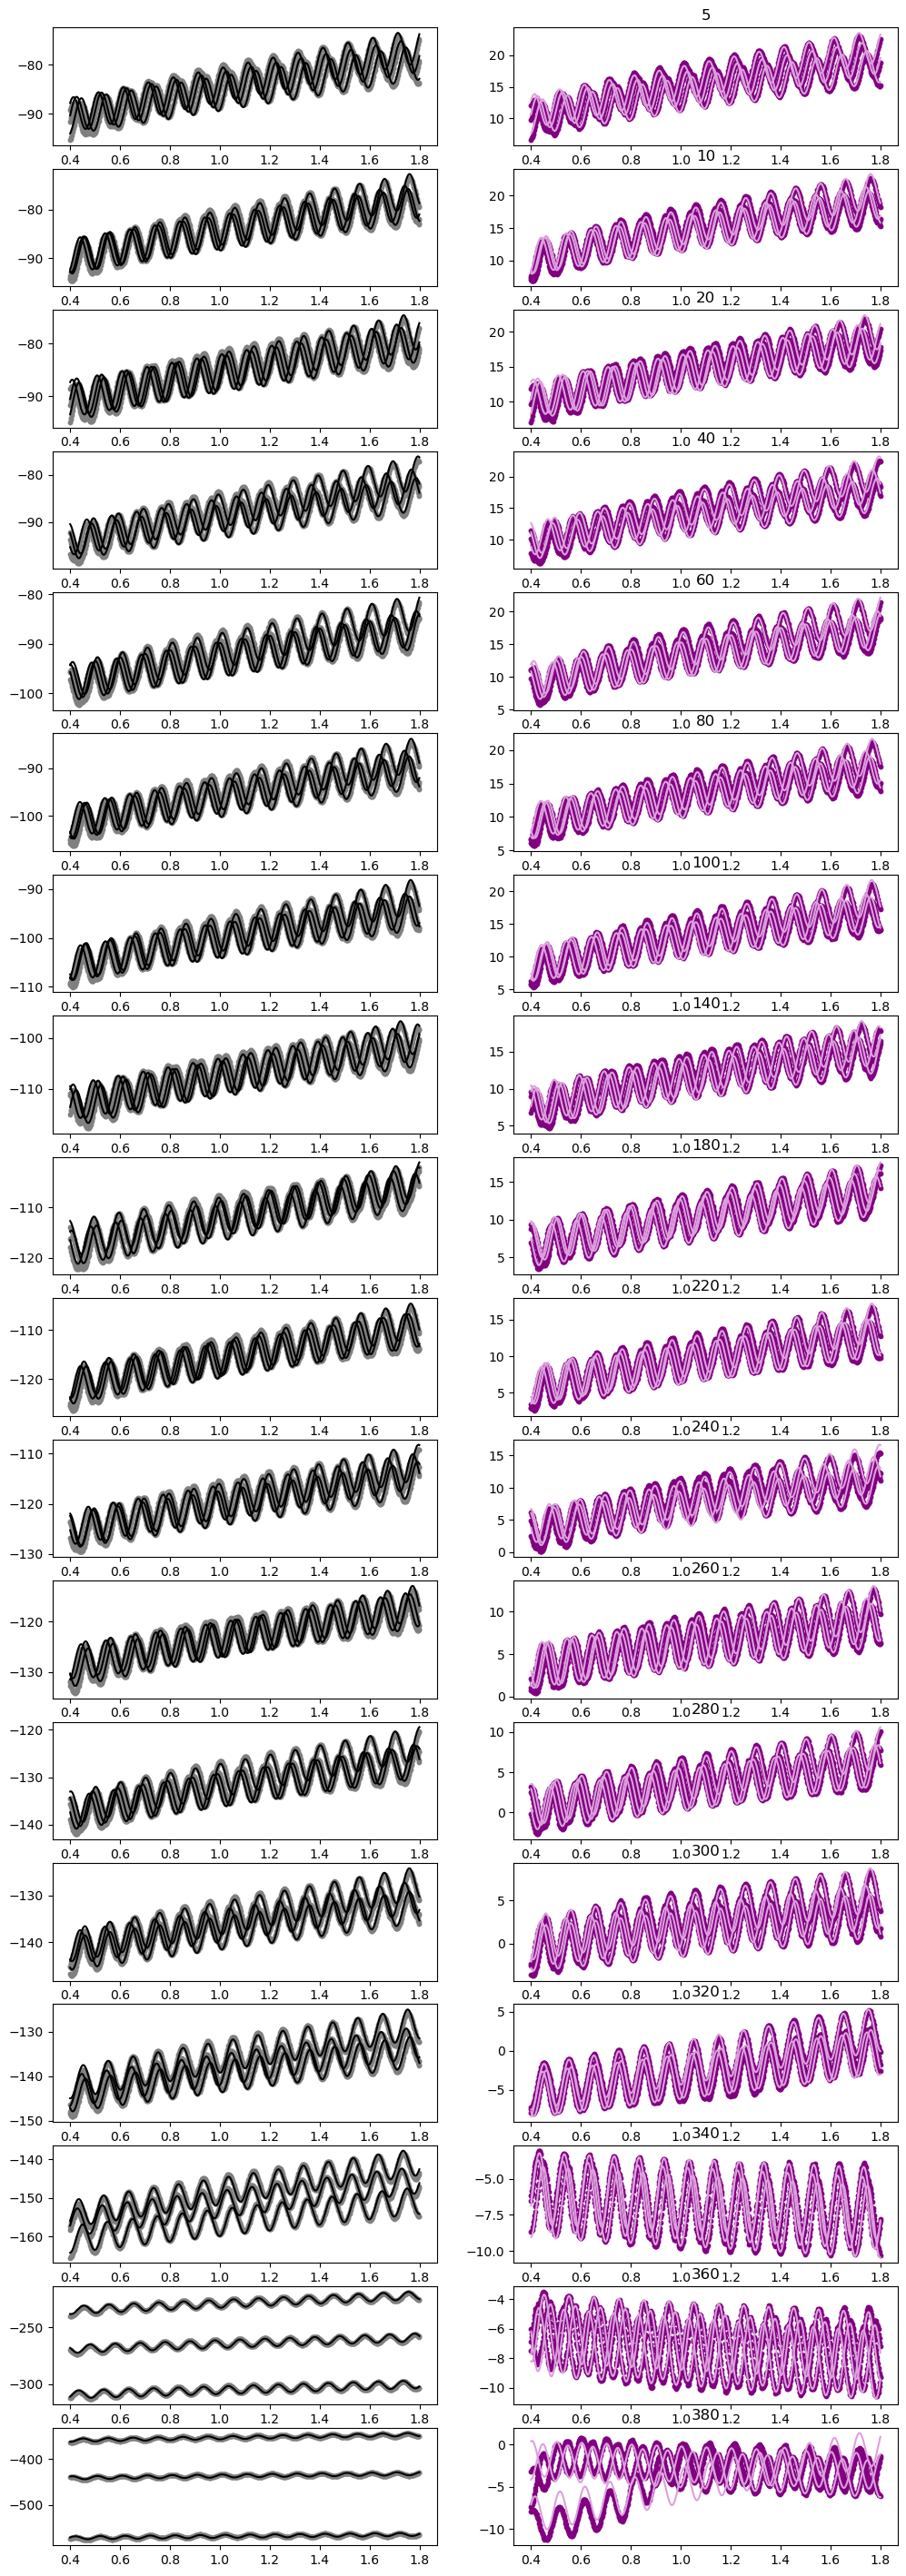

In [16]:
filepath=r'example_data\1\\'

fig2,ax2=plt.subplots(len(IRfreqs),2,figsize=(12,len(IRfreqs)*2))

combdf=pd.DataFrame()
for x in [1,2,3]:
    N=x
    psi=[]
    phi=[]
    Zamp=[]
    Damp=[]
    for n in range(len(IRfreqs)):
        I=N
        if I<100:
            In="0"+str(I)
            if I<10:
                In='00'+str(I)
        else:
            In=str(I)
        file=filepath+'{}.0_00{}.spm'.format(IRfreqs[n],In)
        with files.HoldCurveFile(file) as file_:
            channel = file_[0]
            hold_plot, ax_properties = channel.create_force_hold_time_plot(METRIC)
            time=hold_plot.x
            d=hold_plot.y
            channel = file_[1]
            hold_plot, ax_properties = channel.create_force_hold_time_plot(METRIC)
            z=hold_plot.y
        
        #height
        x=time[200:-100]
        y=z[200:-100]
        ax2[n,0].scatter(x,y,s=10,color="grey")
        bounds=[[0,0,-np.inf,-np.inf],[np.inf,np.inf,np.inf,np.inf]]
        z_guess,z_guess_err = curve_fit(sinewlinearBL,x,y,p0=[3,10,0,0],bounds=bounds)
        yfit=sinewlinearBL(x,*z_guess)
        ax2[n,0].plot(x,yfit,c='k')
        
        
        #defl
        ax3=ax2[n,1]
        X=time[200:-100]
        Y=d[200:-100]
        ax3.scatter(X,Y,s=10,color="purple")
        
        d_guess,d_guess_err = curve_fit(sinewlinearBL,X,Y,p0=[5,z_guess[1],0,0],bounds=bounds)
        Yfit=sinewlinearBL(X,*d_guess)
        ax3.plot(X,Yfit,c='plum')
        ax3.set_title(IRfreqs[n])

        
        #yfit_noBL=sine(x,z_guess[0],z_guess[1],y.mean())
        psi.append(z_guess[1])
        phi.append(d_guess[1])
        Zamp.append(z_guess[0])
        Damp.append(d_guess[0])

    calibrationps=-0.044459
    lt=[]
    ps=[]
    sp=[]
    spp=[]
    dzr=[]
    for n in range(len(IRfreqs)):
    
        phaseshift=phi[n]-psi[n]-calibrationps
        DZr=(Damp[n]/Zamp[n])
    
        ps.append(phaseshift)
        dzr.append(DZr)
        sp.append(DZr*(np.cos(phaseshift)-DZr)/
                  ((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))
    
        spp.append(DZr*np.sin(phaseshift)/
                  ((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))
         
    
        lt.append(np.sin(phaseshift)/(np.cos(phaseshift)-DZr))
    
    combined=pd.DataFrame({'lt':lt,
             'ps':ps,
             'sp':sp,
             'spp':spp})
    pd.set_option('display.max_rows', None)
    combdf=pd.concat([combdf,combined],axis=1)

In [20]:
radius0=[]
radius1=[]
radius2=[]

radlist={0:radius0,
        1:radius1,
        2:radius2,
}

consep0=[]
consep1=[]
consep2=[]


conseplist={0:consep0,
        1:consep1,
        2:consep2,
}

Padh0=[]
Padh1=[]
Padh2=[]


Padhlist={0:Padh0,
        1:Padh1,
        2:Padh2,
}


for f in range(3):
    radl=radlist[f]
    consep=conseplist[f]
    padh=Padhlist[f]
    for n in range(len(IRfreqs)):
        I=f+1
        if I<100:
            In="0"+str(I)
            if I<10:
                In='00'+str(I)
        else:
            In=str(I)
        file=r'example_data\1\{}.0_00{}.spm'.format(IRfreqs[n],In)
        with files.HoldCurveFile(file) as file_:
            channel = file_[0]
            d_plot, ax_properties = channel.create_force_z_plot(FORCE)
            tracesep, retracesep= channel.compute_separation(d_plot,FORCE)
            trace=pd.DataFrame(tracesep).T
            retrace=pd.DataFrame(retracesep).T
    
            k=channel.spring_constant
            R=25
            blf=20
            fitboundary=[0,80]
            minimum_i=retrace.iloc[:,1].idxmin()
            
            minffb=int((1-fitboundary[0]/100)*minimum_i)
            maxffb=int((1-fitboundary[1]/100)*minimum_i)
            
            baselinefit=retrace.iloc[-blf:,1].mean()
            
            retrace[2]=retrace[1]-baselinefit
            #retrace[2]=retrace[1]
    
            contactsep=retrace[0][minimum_i]-retrace[0][0]
            consep.append(contactsep)
            
            Padh=(retrace[2][minimum_i])
            gamma = -2 * Padh / (3 * np.pi * R)
            padh.append(Padh)
            
            fittingregion=retrace[maxffb:minffb+1]
            def xterm(p,Padh):
                #Padh=abs(Padh)
                u=(1+np.sqrt(1-p/Padh))/2
                return (u**(4/3)-2/3*u**(1/3))
            
            test=xterm(fittingregion[2],Padh)
      
            m, c = np.polyfit(test, fittingregion[0], 1)
            
            radl.append(np.sqrt(abs(m)*R))

In [21]:
# convert a0 to ac

#radlist
#conseplist


def equation(a, delta, R, a0):
    return a**2 * (1 - (2/3)*(a0/a)**(3/2)) - delta*R

ac0=[]
ac1=[]
ac2=[]

aclist={0:ac0,1:ac1,2:ac2}

for f in range(3):
    deltal=conseplist[f]
    a0l=radlist[f]
    acl=aclist[f]
    for n in range(len(a0l)):
        a0=a0l[n]
        delta=deltal[n]
        R=25

        ac_initial = a0
        
        a_solution = fsolve(equation, ac_initial, args=(delta, R, a0))[0]
        acl.append(a_solution)

ac=pd.DataFrame(aclist)
ac

,0,1,2
0,29.477695,28.414738,28.485703
1,28.610966,27.868410,28.575022
2,29.339711,27.895077,28.414425
3,28.820914,28.350368,27.997520
4,28.365743,27.923410,26.895505
5,28.269107,28.439152,28.335660
6,28.426643,27.795520,27.373557
7,29.053666,28.896810,28.322092
8,28.936257,28.016899,27.496874
9,29.546719,28.630943,29.188269


In [22]:
LT={}
PS={}
SP={}
SPP={}
combined=[LT,PS,SP,SPP]
for x in range(3):
    df=combdf.iloc[:,x*4:x*4+4]
    for n in range(4):
        dic=combined[n]
        dic[x]=df.iloc[:,n]

#E'
df=pd.DataFrame(combined[2])/ac/2*40

#tan(delta)
df2=pd.DataFrame(combined[0])

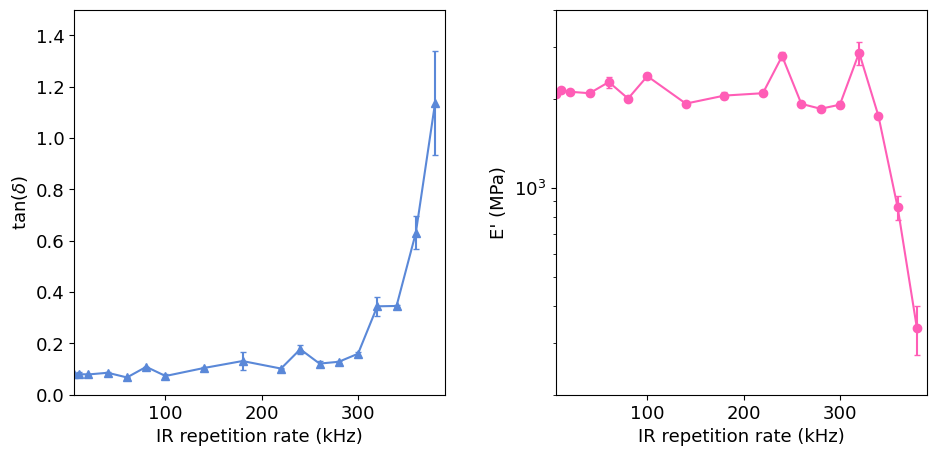

In [23]:
plt.rcParams['font.size']=13
fig1,Ax=plt.subplots(1,2,figsize=(11,5))

markers=['^','o']
labels=['tan($\delta$)',"Storage modulus"]


ax1=Ax[0]
ax2=Ax[1]

ax1.errorbar(IRfreqs,df2.mean(axis=1),yerr=df2.std(axis=1),capsize=2,markersize=6,marker='^',color="#5A88D8")
ax2.errorbar(IRfreqs,df.mean(axis=1)*10**3,yerr=df.std(axis=1)*10**3,capsize=2,markersize=6,marker='o',color="#FF5DB6")

ax2.set(ylim=(200,4000),xlabel='IR repetition rate (kHz)',ylabel="E' (MPa)",xlim=(5,390),yscale='log',xscale='linear')
ax1.set(ylim=(0,1.5),ylabel='tan($\delta$)',xlabel='IR repetition rate (kHz)',xlim=(5,390))

plt.subplots_adjust(wspace=0.3)